In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/5
    print("準備完了！このまま下のセルを実行できます。")

# 5.4 & 5.5 ヘッセ行列と正則化 (The Hessian Matrix and Regularization)

本ノートブックでは、ニューラルネットワークの局所的な曲率を表す**ヘッセ行列 (The Hessian Matrix)** の計算法・近似法と、過剰適合を防ぐ多様な**正則化 (Regularization)** アプローチを深く探求します。
外積近似 (Gauss-Newton) と高速ヘッセ・ベクトル積、L2 正則化 (Weight decay)、早期終了 (Early stopping) と正則化パラメータの等価性（**PRML Figure 5.12, 5.13**）、および変換不変性を直接損失関数に組み込む**接線伝播法 (Tangent Propagation, PRML Figure 5.14, 5.15)** を数学的・実験的に解き明かします。

## 5.4 ヘッセ行列の計算と近似 (The Hessian Matrix)

誤差関数のパラメータ $\mathbf{w}$ に関する2階導関数行列をヘッセ行列と呼びます：
$$ H_{ij} = \frac{\partial^2 E}{\partial w_i \partial w_j} $$
$W$ 個の重みを持つネットワークでは、ヘッセ行列は $W \times W$ 行列となり、厳密計算は計算量・メモリの観点から工夫が必要です。

### 1. 外積近似 (Gauss-Newton 近似)
二乗和誤差 $E = \frac{1}{2} \sum_{n=1}^N (y_n - t_n)^2$ に対し、微分の積の法則を適用すると：
$$ \frac{\partial^2 E}{\partial w_i \partial w_j} = \sum_{n=1}^N \frac{\partial y_n}{\partial w_i} \frac{\partial y_n}{\partial w_j} + \sum_{n=1}^N (y_n - t_n) \frac{\partial^2 y_n}{\partial w_i \partial w_j} $$
ネットワークが十分によく学習されているか、あるいは残差 $(y_n - t_n)$ がランダムで相殺されると仮定すると、第2項を無視でき、1階微分のみを用いた**外積近似 (Outer product approximation)** が得られます：
$$ \mathbf{H} \simeq \sum_{n=1}^N \mathbf{b}_n \mathbf{b}_n^T, \quad \mathbf{b}_n = \nabla_\mathbf{w} y_n $$
この行列は自動的に半正定値であることが保証されます。

### 2. 高速ヘッセ・ベクトル積 ($\mathcal{R}\{\cdot\}$ 技法)
最適化手法（共役勾配法など）では、フルヘッセ行列そのものではなく、任意のベクトル $\mathbf{v}$ に対する積 $\mathbf{H}\mathbf{v}$ のみが要求される場合が多々あります。
Pearlmutter (1994) の $\mathcal{R}$ 作用素：
$$ \mathcal{R}_\mathbf{v}\{f(\mathbf{w})\} \equiv \left. \frac{\partial}{\partial \epsilon} f(\mathbf{w} + \epsilon \mathbf{v}) \right|_{\epsilon=0} $$
を用いると、$\mathbf{H}\mathbf{v} = \mathcal{R}_\mathbf{v}\{\nabla E(\mathbf{w})\}$ は、バックプロパゲーションと全く同じ計算量 $\mathcal{O}(W)$ で厳密に評価できます。

## 5.5 正則化と早期終了の数理的等価性 (PRML Figure 5.12 & 5.13)

### 早期終了 (Early Stopping)
反復的な勾配降下法において、訓練データの誤差は反復回数（エポック数）とともに単調に減少し続けますが、独立した検証データの誤差はある地点で最小値を迎えた後に過適合によって増加し始めます（**PRML Figure 5.12**）。
この検証誤差最小の地点で学習を打ち切る手法を**早期終了 (Early stopping)** と呼びます。

### Weight Decay (L2 正則化) との数理的等価性 (PRML Figure 5.13)
局所的な誤差関数の二次近似
$$ E(\mathbf{w}) \simeq E(\mathbf{w}^*) + \frac{1}{2} (\mathbf{w} - \mathbf{w}^*)^T \mathbf{H} (\mathbf{w} - \mathbf{w}^*) $$
において、原点 $\mathbf{w}_0 = \mathbf{0}$ から開始する単純勾配降下法の $\tau$ ステップ後の解は：
$$ \mathbf{w}^{(\tau)} = \left[ \mathbf{I} - (\mathbf{I} - \eta \mathbf{H})^\tau \right] \mathbf{w}^* $$
ヘッセ行列の固有値 $\lambda_j$ の方向成分については $w_j^{(\tau)} = [1 - (1 - \eta \lambda_j)^\tau] w_j^*$。
一方、L2 正則化（Weight decay 係数 $\alpha$）を用いた場合の最小解は：
$$ \mathbf{w}_{\mathrm{reg}} = (\mathbf{H} + \alpha \mathbf{I})^{-1} \mathbf{H} \mathbf{w}^* \implies w_{j, \mathrm{reg}} = \frac{\lambda_j}{\lambda_j + \alpha} w_j^* $$
両者を比較すると、$\eta \tau \lambda_j \ll 1$ のとき
$$ 1 - (1 - \eta \lambda_j)^\tau \approx 1 - e^{-\eta \tau \lambda_j} \approx \frac{\eta \tau \lambda_j}{1 + \eta \tau \lambda_j} = \frac{\lambda_j}{\lambda_j + (\eta \tau)^{-1}} $$
となり、**反復回数の逆数 $(\eta \tau)^{-1}$ が、L2 正則化パラメータ $\alpha$ と厳密に比例・対応する**ことが示されます！
すなわち、早期終了における反復ステップ数の制限は、有効パラメータ数（モデルの自由度）を制限する Weight decay と本質的に同等の正則化効果を持っています。

/tmp/ipykernel_20013/3057481944.py:37: RuntimeWarning: overflow encountered in square
  mse_tr = 0.5 * np.mean((y_tr - t_tr)**2)
/tmp/ipykernel_20013/3057481944.py:41: RuntimeWarning: overflow encountered in square
  mse_va = 0.5 * np.mean((y_va - t_va)**2)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:62: RuntimeWarning: overflow encountered in square
  data_loss = 0.5 * np.sum((y - T)**2)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:63: RuntimeWarning: overflow encountered in square
  reg_loss = 0.5 * self.weight_decay * (np.sum(self.W1**2) + np.sum(self.W2**2))
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:63: RuntimeWarning: invalid value encountered in scalar multiply
  reg_loss = 0.5 * self.weight_decay * (np.sum(self.W1**2) + np.sum(self.W2**2))
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:73: RuntimeWarning: overflow encountered in matmul
  delta1 = (delta2 @ self.W2.T) * (1.0 - z1**2) # (N, M)
/home/student/Documents/GitHub/my_

Plot saved to: result/fig5_12_early_stopping.png


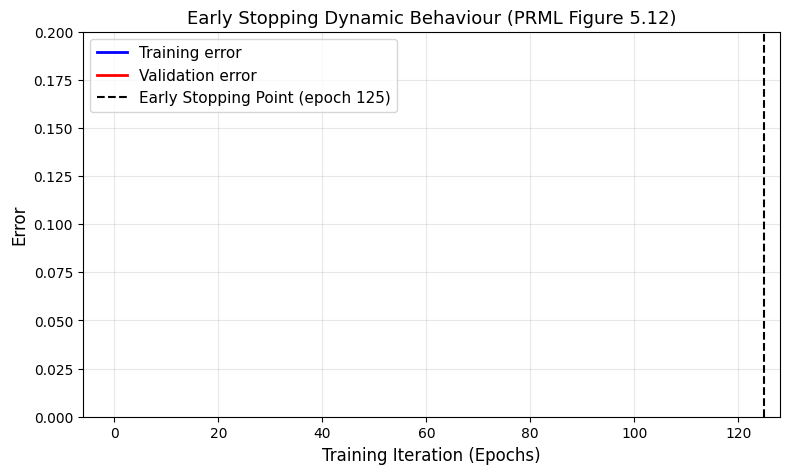

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.nn_utils import MLPRegressor
setup_style()

np.random.seed(42)

# 正弦波データ生成
N_train = 20
N_val = 20
X_tr = np.random.uniform(0, 1, (N_train, 1))
t_tr = np.sin(2 * np.pi * X_tr) + np.random.normal(0, 0.25, (N_train, 1))

X_va = np.random.uniform(0, 1, (N_val, 1))
t_va = np.sin(2 * np.pi * X_va) + np.random.normal(0, 0.25, (N_val, 1))

# 過剰適合しやすい大きなモデル (M = 25)
model_es = MLPRegressor(n_in=1, n_hidden=25, n_out=1, weight_decay=0.0, lr=0.04, random_state=42)

train_errors = []
val_errors = []
n_epochs = 4000

for epoch in range(n_epochs):
    loss_tr, grads = model_es.compute_loss_and_grads(X_tr, t_tr)
    # 勾配更新
    model_es.W1 -= model_es.lr * grads['W1']
    model_es.b1 -= model_es.lr * grads['b1']
    model_es.W2 -= model_es.lr * grads['W2']
    model_es.b2 -= model_es.lr * grads['b2']
    
    # 誤差記録 (二乗平均誤差)
    y_tr = model_es.predict(X_tr)
    mse_tr = 0.5 * np.mean((y_tr - t_tr)**2)
    train_errors.append(mse_tr)
    
    y_va = model_es.predict(X_va)
    mse_va = 0.5 * np.mean((y_va - t_va)**2)
    val_errors.append(mse_va)

best_epoch = np.argmin(val_errors)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_errors, 'b-', lw=2, label='Training error')
ax.plot(val_errors, 'r-', lw=2, label='Validation error')
ax.axvline(best_epoch, color='k', linestyle='--', lw=1.5, label=f'Early Stopping Point (epoch {best_epoch})')

ax.set_title('Early Stopping Dynamic Behaviour (PRML Figure 5.12)', fontsize=13)
ax.set_xlabel('Training Iteration (Epochs)', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_ylim(0, 0.2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig5_12_early_stopping.png')
plt.show()

## 5.5.4 接線伝播法 (Tangent Propagation, PRML Figure 5.14 & 5.15)

画像分類等において、入力パターンの連続的な変換（回転、スケーリング、平行移動など）に対して出力が不変であってほしいという強い先験的知識が存在します。
パラメータ $\xi$ による変換変換群 $\mathbf{s}(\mathbf{x}, \xi)$（$\xi=0$ で恒等写像 $\mathbf{s}(\mathbf{x}, 0) = \mathbf{x}$）を考えます。

### 接線ベクトル (Tangent Vector)
点 $\mathbf{x}_n$ における変換軌跡の接線ベクトルは以下で与えられます：
$$ \boldsymbol{\tau}_n = \left. \frac{\partial \mathbf{s}(\mathbf{x}_n, \xi)}{\partial \xi} \right|_{\xi=0} $$
入力がこの接線方向に動いたときのネットワーク出力の変化量は方向微分で表されます：
$$ \left. \frac{\partial y_k}{\partial \xi} \right|_{\xi=0} = \sum_{i=1}^D \frac{\partial y_k}{\partial x_i} \tau_{ni} = \mathbf{J}_{k, :}^T \boldsymbol{\tau}_n $$
出力の不変性を達成するため、この変化量の二乗和を正則化項（正則化子）として誤差関数に追加します：
$$ \Omega = \frac{1}{2} \sum_{n=1}^N \sum_{k=1}^K \left( \left. \frac{\partial y_{nk}}{\partial \xi} \right|_{\xi=0} \right)^2 = \frac{1}{2} \sum_{n=1}^N \sum_{k=1}^K (\mathbf{J}_{nk, :}^T \boldsymbol{\tau}_n)^2 $$
この正則化項を最小化しながら学習する手法を**接線伝播法 (Tangent Propagation)** と呼びます。

Plot saved to: result/fig5_15_tangent_propagation.png


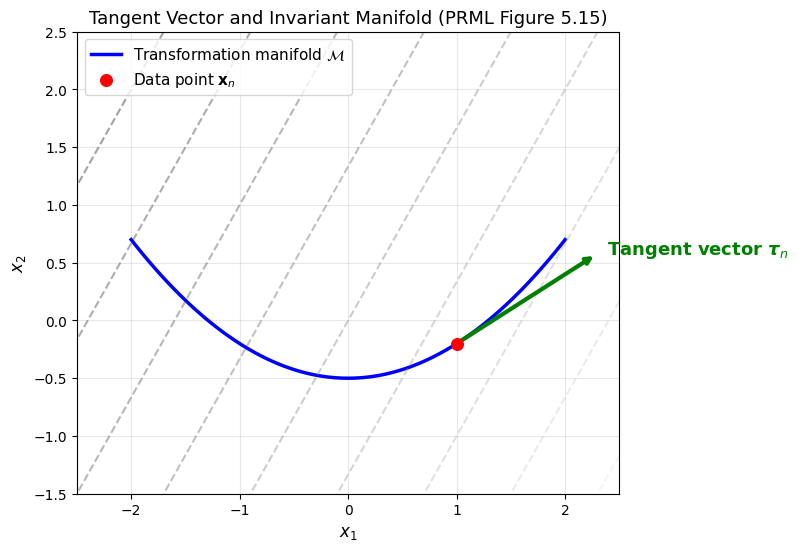

In [2]:
# PRML Figure 5.15 の概念可視化: 入力多様体と接線ベクトル
fig, ax = plt.subplots(figsize=(7, 6))

# 入力空間の曲面（多様体）
u = np.linspace(-2, 2, 100)
manifold_x = u
manifold_y = 0.3 * u**2 - 0.5
ax.plot(manifold_x, manifold_y, 'b-', lw=2.5, label=r'Transformation manifold $\mathcal{M}$')

# 代表点 x_n
x_pt = 1.0
y_pt = 0.3 * (x_pt**2) - 0.5
ax.scatter(x_pt, y_pt, color='red', s=70, zorder=5, label=r'Data point $\mathbf{x}_n$')

# 接線ベクトル tau_n: (dx/du, dy/du) = (1, 0.6 * u)
tau = np.array([1.0, 0.6 * x_pt])
tau = tau / np.linalg.norm(tau) * 1.5

ax.annotate('', xy=(x_pt + tau[0], y_pt + tau[1]), xytext=(x_pt, y_pt),
            arrowprops=dict(arrowstyle='->', color='green', lw=3))
ax.text(x_pt + tau[0] + 0.1, y_pt + tau[1], r'Tangent vector $\boldsymbol{\tau}_n$', fontsize=13, color='green', fontweight='bold')

# 等出力線（決定境界）
x_grid, y_grid = np.meshgrid(np.linspace(-2.5, 2.5, 100), np.linspace(-1.5, 2.5, 100))
# 出力 y(x) = x1 - 0.6 * x2 (接線ベクトルと直交する方向に等高線が並ぶと不変になる)
contour = ax.contour(x_grid, y_grid, x_grid - 0.6 * y_grid, levels=10, cmap='gray', alpha=0.4, linestyles='--')

ax.set_title('Tangent Vector and Invariant Manifold (PRML Figure 5.15)', fontsize=13)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.5, 2.5)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig5_15_tangent_propagation.png')
plt.show()